# Hybrid QA Generation Pipeline (Rule-based + LLM)

This notebook demonstrates the **Document VQA Generation** pipeline:

## Pipeline Flow:
1. **Input**: Document graph JSON (nodes + edges from layout analysis)
2. **Rule-based QA**: Form/Table/Figure regions → Template-based questions
3. **LLM QA**: Long text + multi-region → Prompt-based generation (with fallback)
4. **Output**: Up to 10 QA pairs per document

## Files Used:
- `src/qa/llm.py` - Main generation logic
- `src/qa/rule_based_templates.json` - Templates for form/table/figure
- `src/qa/llm_prompt_templates.json` - LLM prompts for multi-region QA
- `output/full_pipeline/` - Processed document graphs

In [1]:
from pathlib import Path
import json
import sys

# Setup paths
sys.path.insert(0, '..')
BASE = Path("../")

# Template paths
RULE_TEMPLATES = BASE / "src/qa/rule_based_templates.json"
LLM_TEMPLATES = BASE / "src/qa/llm_prompt_templates.json"

# Check files exist
print("=" * 60)
print(" File Paths Check")
print("=" * 60)
print(f"Rule templates: {RULE_TEMPLATES.resolve()}")
print(f"  → Exists: {RULE_TEMPLATES.exists()}")
print(f"LLM templates: {LLM_TEMPLATES.resolve()}")
print(f"  → Exists: {LLM_TEMPLATES.exists()}")

# Load templates
rule_templates = json.loads(RULE_TEMPLATES.read_text(encoding="utf-8"))
llm_templates = json.loads(LLM_TEMPLATES.read_text(encoding="utf-8"))

print(f"\n Rule Templates: {len(rule_templates.get('templates', []))} templates loaded")
print(f" LLM Templates: {len(llm_templates.get('prompt_templates', {}))} prompt types")

 File Paths Check
Rule templates: D:\Thach\HUST\Project_1\VQA\code\src\qa\rule_based_templates.json
  → Exists: True
LLM templates: D:\Thach\HUST\Project_1\VQA\code\src\qa\llm_prompt_templates.json
  → Exists: True

 Rule Templates: 12 templates loaded
 LLM Templates: 5 prompt types


## 1️. Load Sample Document

In [2]:
# Choose a sample document
DOC_PATH = BASE / "output/full_pipeline/test/1016.json"

print("=" * 60)
print(" Loading Document")
print("=" * 60)
print(f"Path: {DOC_PATH.resolve()}")
print(f"Exists: {DOC_PATH.exists()}")

doc = json.loads(DOC_PATH.read_text(encoding="utf-8"))

# Display document structure
print(f"\n Document Statistics:")
print(f"  - Nodes: {len(doc.get('nodes', []))}")
print(f"  - Edges: {len(doc.get('edges', []))}")
print(f"  - Source image: {doc.get('metadata', {}).get('source_image', 'N/A')}")

# Show node types distribution
from collections import Counter
node_types = [n.get('region_type', 'unknown') for n in doc.get('nodes', [])]
print(f"\n Region Types:")
for rtype, count in Counter(node_types).items():
    print(f"  - {rtype}: {count}")

 Loading Document
Path: D:\Thach\HUST\Project_1\VQA\code\output\full_pipeline\test\1016.json
Exists: True

 Document Statistics:
  - Nodes: 3
  - Edges: 6
  - Source image: 1016.png

 Region Types:
  - text: 1
  - form: 2


## 2️. Generate QA Pairs

In [3]:
# Import the QA generator (reload to get latest changes)
import importlib
import src.qa.llm as llm_module
importlib.reload(llm_module)

from src.qa.llm import generate_qas, region_category, LLMBackend

print("=" * 60)
print(" Generating QA Pairs")
print("=" * 60)

# Check LLM availability
llm_backend = LLMBackend()
llm_backend.try_load()
print(f"LLM Backend Available: {llm_backend.available}")
if not llm_backend.available:
    print("  → Using deterministic fallback for multi-region QAs")

# Generate QAs
qas = generate_qas(doc, rule_templates, llm_templates, max_qas=10)

print(f"\n Generated {len(qas)} QA pairs")

# Analyze QA types
reasoning_types = Counter([qa.get('reasoning_type', 'unknown') for qa in qas])
print(f"\n Reasoning Types:")
for rtype, count in reasoning_types.items():
    print(f"  - {rtype}: {count}")

 Generating QA Pairs


c:\Users\Thach\miniconda3\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM Backend Available: False
  → Using deterministic fallback for multi-region QAs

 Generated 3 QA pairs

 Reasoning Types:
  - lookup: 2
  - comprehension: 1


In [4]:
import pandas as pd

# Create detailed DataFrame
df = pd.DataFrame(qas)

# Display with better formatting
pd.set_option('display.max_colwidth', 100)
print("=" * 60)
print(" Generated QA Pairs (Table View)")
print("=" * 60)

# Show key columns
display_cols = ['question', 'answer', 'reasoning_type', 'evidence_region_ids']
df[display_cols]

 Generated QA Pairs (Table View)


,question,answer,reasoning_type,evidence_region_ids
0,What is the Attn?,"General manager,Pharmaceutical International Division",lookup,[2]
1,What is the Fax?,81-6-204-2943,lookup,[2]
2,What is the main topic or content discussed in this section?,"If you are in agreement with the above terms and conditions,please indicate acceptance by return...",comprehension,[0]


In [5]:
# Test với document khác có form fields
TEST_DOC_PATH = BASE / "output/full_pipeline/test/1016.json"

if TEST_DOC_PATH.exists():
    test_doc = json.loads(TEST_DOC_PATH.read_text(encoding="utf-8"))
    print(f" Testing with: {TEST_DOC_PATH.name}")
    print(f"Nodes: {len(test_doc.get('nodes', []))}")
    
    # Show node types
    from collections import Counter
    node_types = [n.get('region_type', 'unknown') for n in test_doc.get('nodes', [])]
    print(f"Region types: {dict(Counter(node_types))}")
    
    # Generate QAs
    importlib.reload(llm_module)
    from src.qa.llm import generate_qas
    test_qas = generate_qas(test_doc, rule_templates, llm_templates, max_qas=10)
    
    print(f"\n Generated {len(test_qas)} QA pairs")
    
    # Show all QAs
    for i, qa in enumerate(test_qas):
        print(f"\n--- QA #{i+1} [{qa.get('reasoning_type')}] ---")
        print(f"Q: {qa.get('question')}")
        print(f"A: {qa.get('answer')[:150]}...")
else:
    print(f" Test file not found: {TEST_DOC_PATH}")

 Testing with: 1016.json
Nodes: 3
Region types: {'text': 1, 'form': 2}

 Generated 3 QA pairs

--- QA #1 [lookup] ---
Q: What is the Attn?
A: General manager,Pharmaceutical International Division...

--- QA #2 [lookup] ---
Q: What is the Fax?
A: 81-6-204-2943...

--- QA #3 [comprehension] ---
Q: What is the main topic or content discussed in this section?
A: If you are in agreement with the above terms and conditions,please indicate acceptance by returning an original signed copy to me and keep the other e...


In [6]:
# Reload module để test với code mới
import importlib
import src.qa.llm as llm_module
importlib.reload(llm_module)
from src.qa.llm import extract_form_fields

test_texts = [
    "Name: John Date: Monday",  # Vấn đề gốc: 2 fields ghép
    "Invoice Number: INV-001 Amount: $500",  # 2 fields ghép
    "Name: John Smith\nDate: 2024-01-15\nAddress: 123 Main St",  # Nhiều lines
    "This is a sentence: another sentence",  # Không phải form (sentence starter)
    "Company: ABC Corp Contact: Mr. X Phone: 123-456",  # 3 fields ghép (without double spaces)
    "It is important: to note this",  # Sentence starter
    "Total: $1,500.00",  # Single field
]

print("=" * 60)
print(" Testing extract_form_fields function")
print("=" * 60)

for text in test_texts:
    fields = extract_form_fields(text)
    print(f"\nInput: '{text}'")
    print(f"Output: {fields}")

 Testing extract_form_fields function

Input: 'Name: John Date: Monday'
Output: [('Name', 'John'), ('Date', 'Monday')]

Input: 'Invoice Number: INV-001 Amount: $500'
Output: [('Invoice Number', 'INV-001'), ('Amount', '$500')]

Input: 'Name: John Smith
Date: 2024-01-15
Address: 123 Main St'
Output: [('Name', 'John Smith'), ('Date', '2024-01-15'), ('Address', '123 Main St')]

Input: 'This is a sentence: another sentence'
Output: []

Input: 'Company: ABC Corp Contact: Mr. X Phone: 123-456'
Output: [('Company', 'ABC Corp'), ('Contact', 'Mr.'), ('X Phone', '123-456')]

Input: 'It is important: to note this'
Output: []

Input: 'Total: $1,500.00'
Output: [('Total', '$1,500.00')]


In [7]:
# Debug: xem text của form nodes trong 1016.json
test_doc = json.loads(TEST_DOC_PATH.read_text(encoding="utf-8"))
for node in test_doc['nodes']:
    if node.get('region_type') == 'form':
        print(f"Node {node['node_id']} (form):")
        print(f"  Text: {node['text'][:200]}...")
        print(f"  Extracted fields: {extract_form_fields(node['text'])}")
        print()

Node 1 (form):
  Text: If you are in agreement with the above terms and conditions,please indicate acceptance by returning an original signed copy to me and keep the other enclosed copy for your files. Thank you for your co...
  Extracted fields: []

Node 2 (form):
  Text: Attn:General manager,Pharmaceutical International Division Fax:81-6-204-2943...
  Extracted fields: [('Attn', 'General manager,Pharmaceutical International Division'), ('Fax', '81-6-204-2943')]



## 3️. Visualize Evidence Regions

If source image exists, draw bounding boxes for evidence regions:

In [8]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

# Build node lookup
nodes = {n["node_id"]: n for n in doc.get("nodes", [])}

# Get source image path
src_img_name = (doc.get("metadata", {}) or {}).get("source_image")
# Determine split from doc path
split = DOC_PATH.parent.name  # 'train', 'test', or 'validation'
src_img_path = BASE / "dataset/DocVQA_Images" / split / src_img_name if src_img_name else None

print("=" * 60)
print(" Image Information")
print("=" * 60)
print(f"Source image: {src_img_name}")
print(f"Image path: {src_img_path}")
print(f"Exists: {src_img_path.exists() if src_img_path else False}")

def bbox_to_rect(bbox):
    """Convert bbox [[x1,y1],[x2,y2],[x3,y3],[x4,y4]] to (left, top, right, bottom)"""
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return (min(xs), min(ys), max(xs), max(ys))

def draw_evidence(image_path, evidence_node_ids, outline="red", width=3):
    """Draw bounding boxes on image for evidence regions"""
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    colors = ["red", "blue", "green", "orange", "purple"]
    
    for i, nid in enumerate(evidence_node_ids):
        node = nodes.get(nid)
        if not node:
            continue
        bbox = node.get("bbox")
        if not bbox:
            continue
        
        left, top, right, bottom = bbox_to_rect(bbox)
        color = colors[i % len(colors)]
        draw.rectangle([left, top, right, bottom], outline=color, width=width)
        
        # Add node ID label
        draw.text((left + 5, top + 5), f"Node {nid}", fill=color)
    
    return img

 Image Information
Source image: 1016.png
Image path: ..\dataset\DocVQA_Images\test\1016.png
Exists: True


 QA Examples with Evidence Visualization

 QA #1
 Question: What is the Attn?
 Answer: General manager,Pharmaceutical International Division
 Evidence Regions: [2]
 Reasoning Type: lookup
 Explanation: Extracted value for 'Attn' from form field.
 Evidence Quotes:
   [1] Attn: General manager,Pharmaceutical International Division...


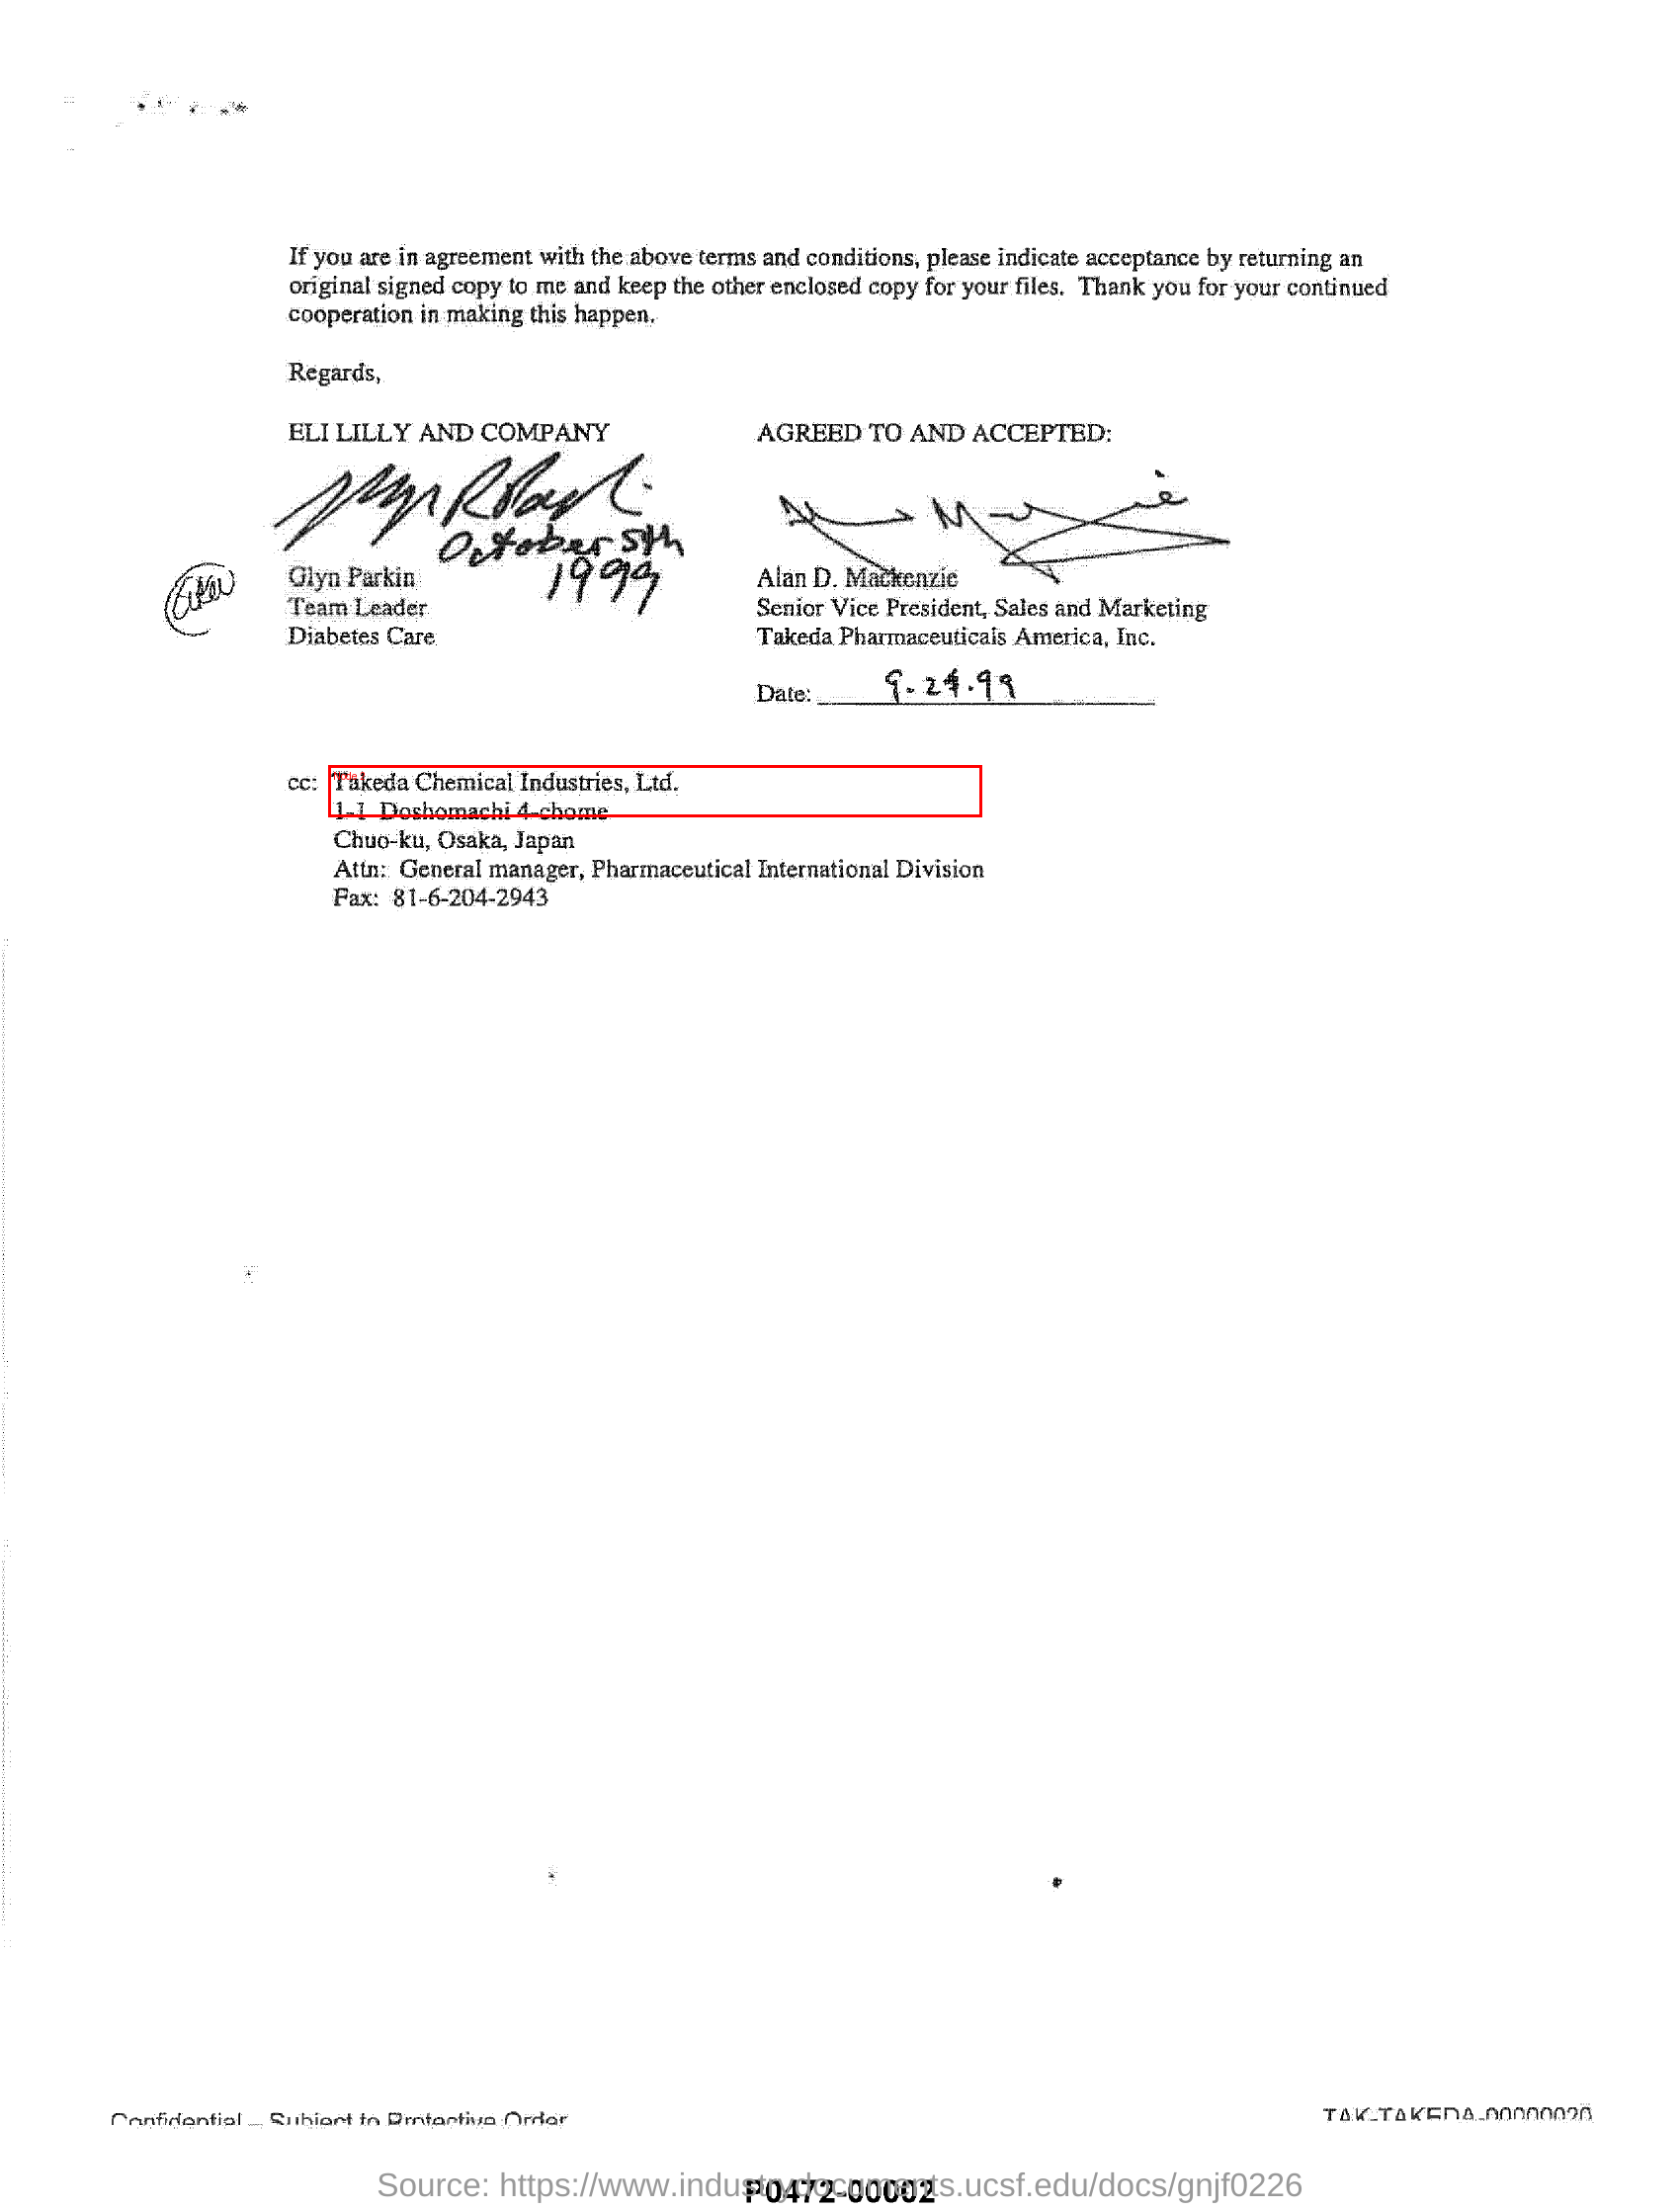


 QA #2
 Question: What is the Fax?
 Answer: 81-6-204-2943
 Evidence Regions: [2]
 Reasoning Type: lookup
 Explanation: Extracted value for 'Fax' from form field.
 Evidence Quotes:
   [1] Fax: 81-6-204-2943...


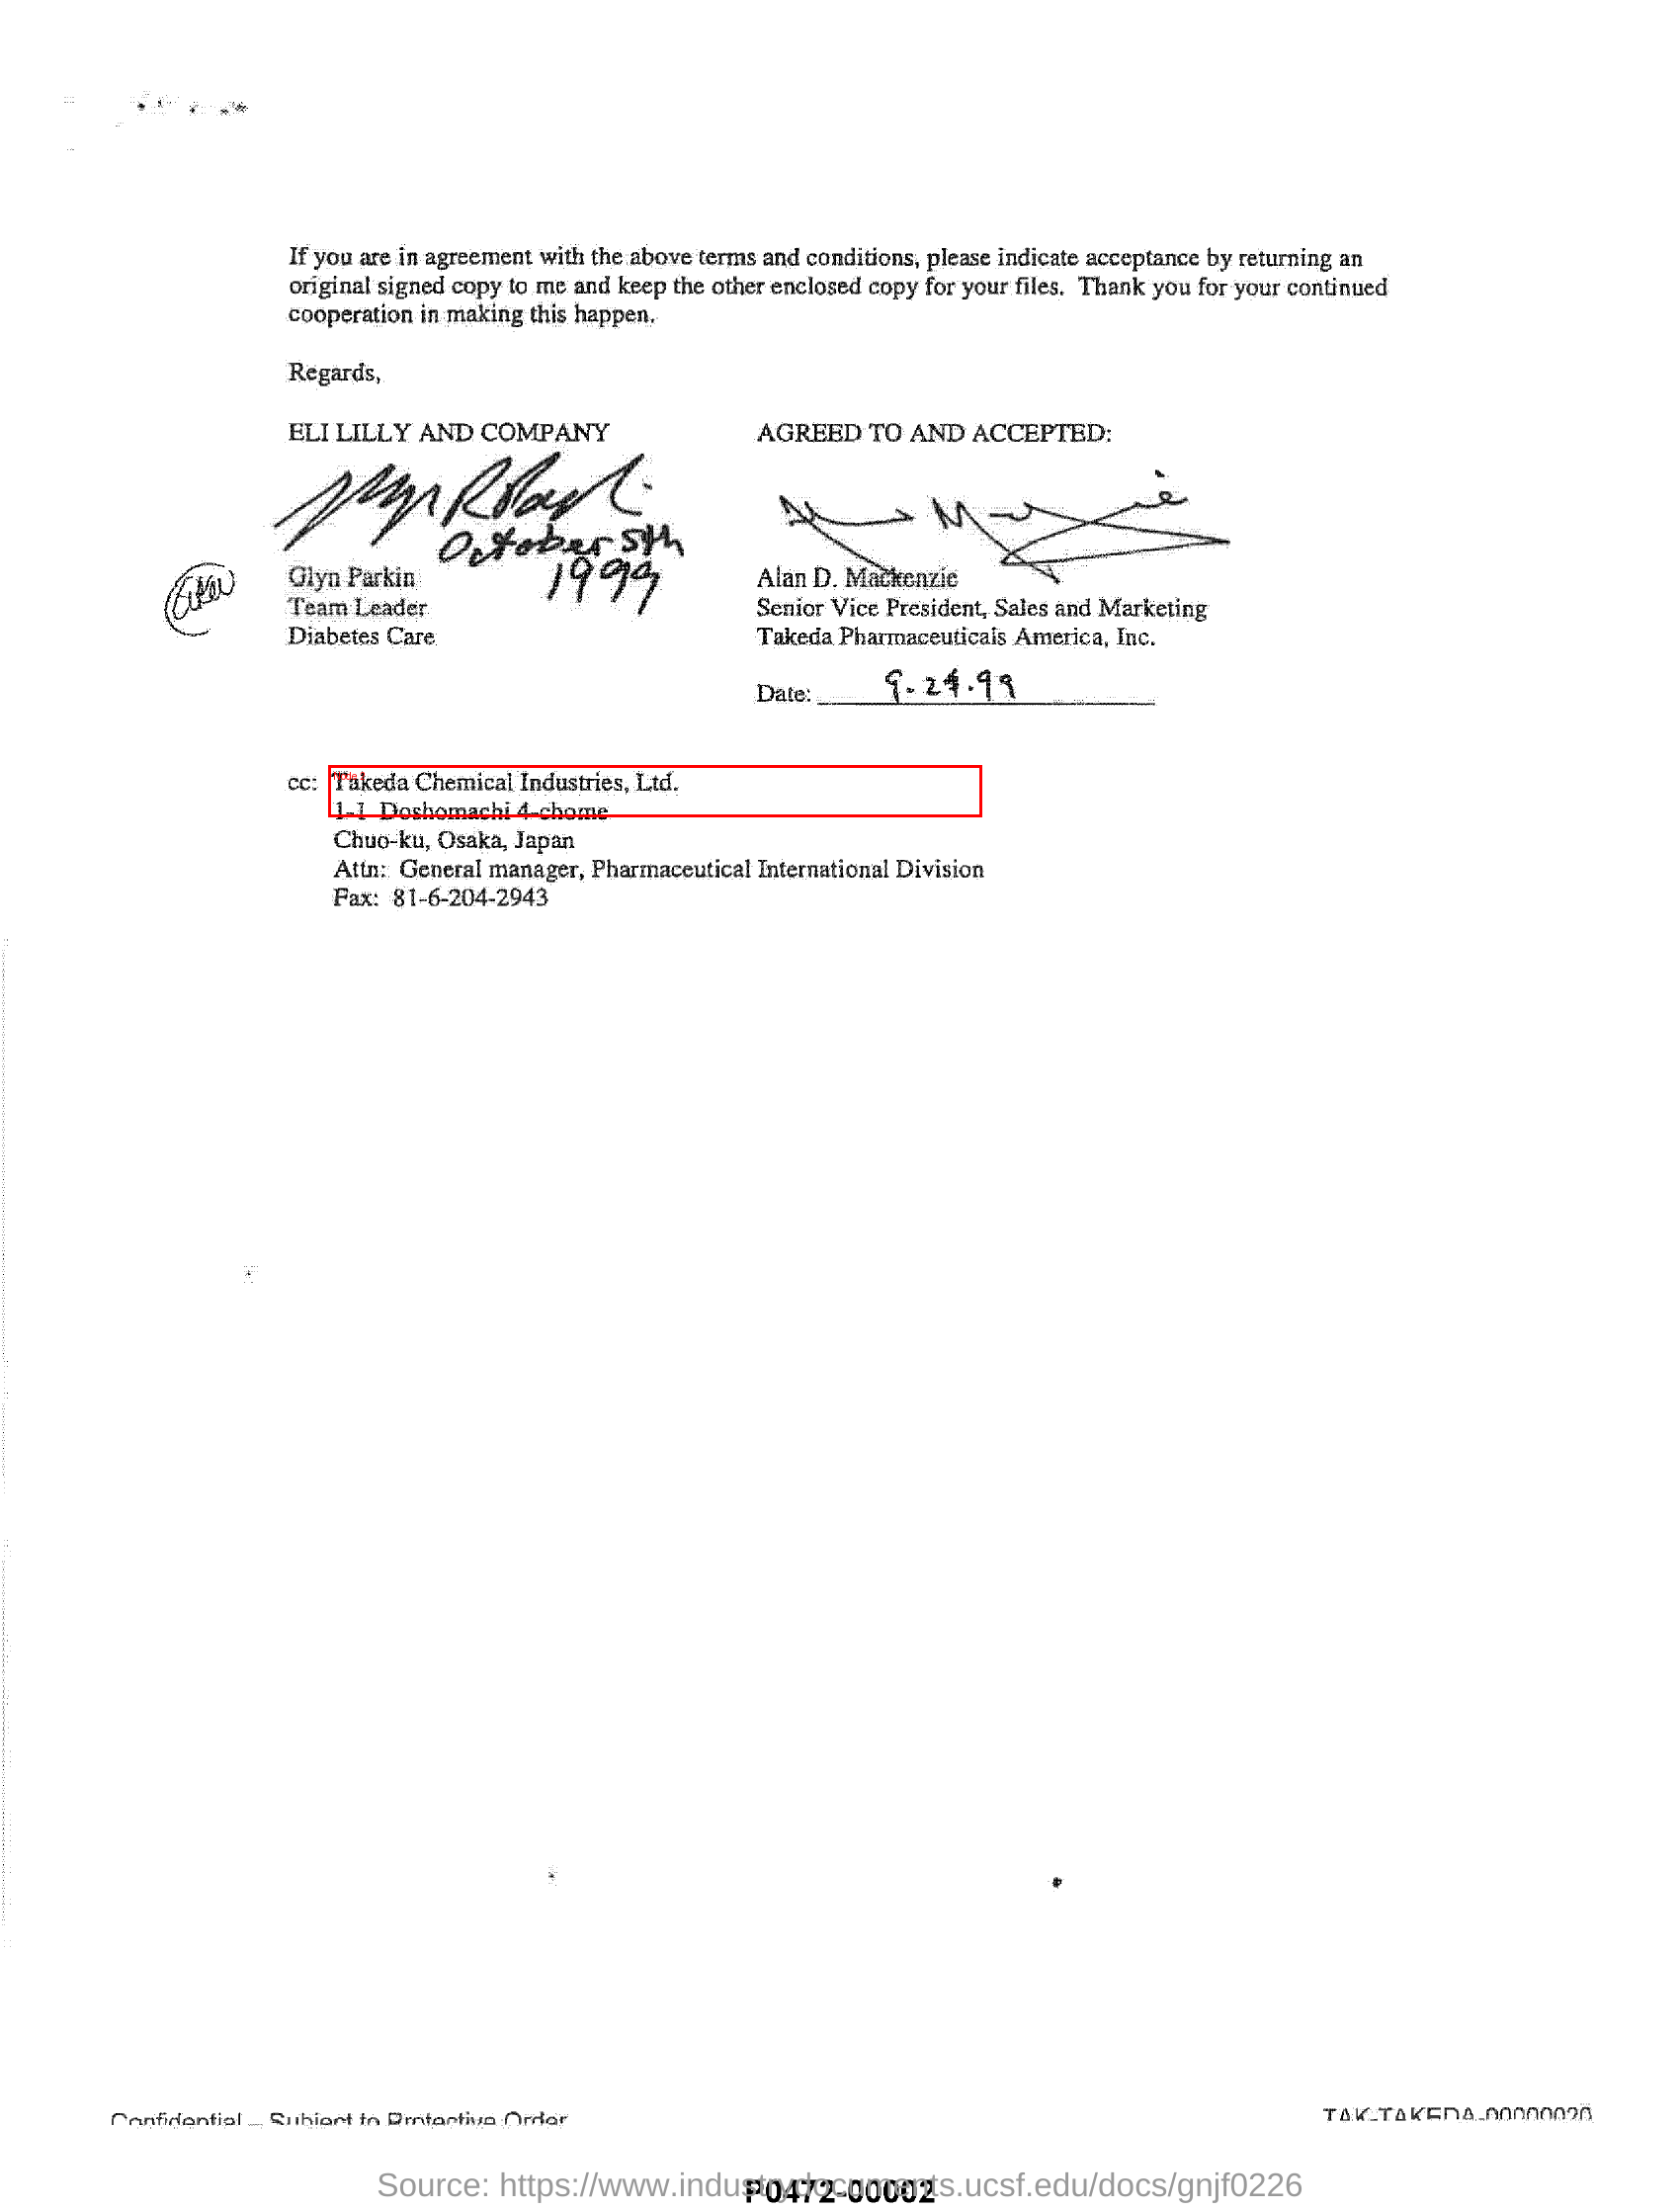


 QA #3
 Question: What is the main topic or content discussed in this section?
 Answer: If you are in agreement with the above terms and conditions,please indicate acceptance by returning an original signed copy to me and keep the other enclosed copy for your files....
 Evidence Regions: [0]
 Reasoning Type: comprehension
 Explanation: Summarized the main content from the text region.
 Evidence Quotes:
   [1] If you are in agreement with the above terms and conditions,please indicate acceptance by returning an original signed copy to me and keep the other e...


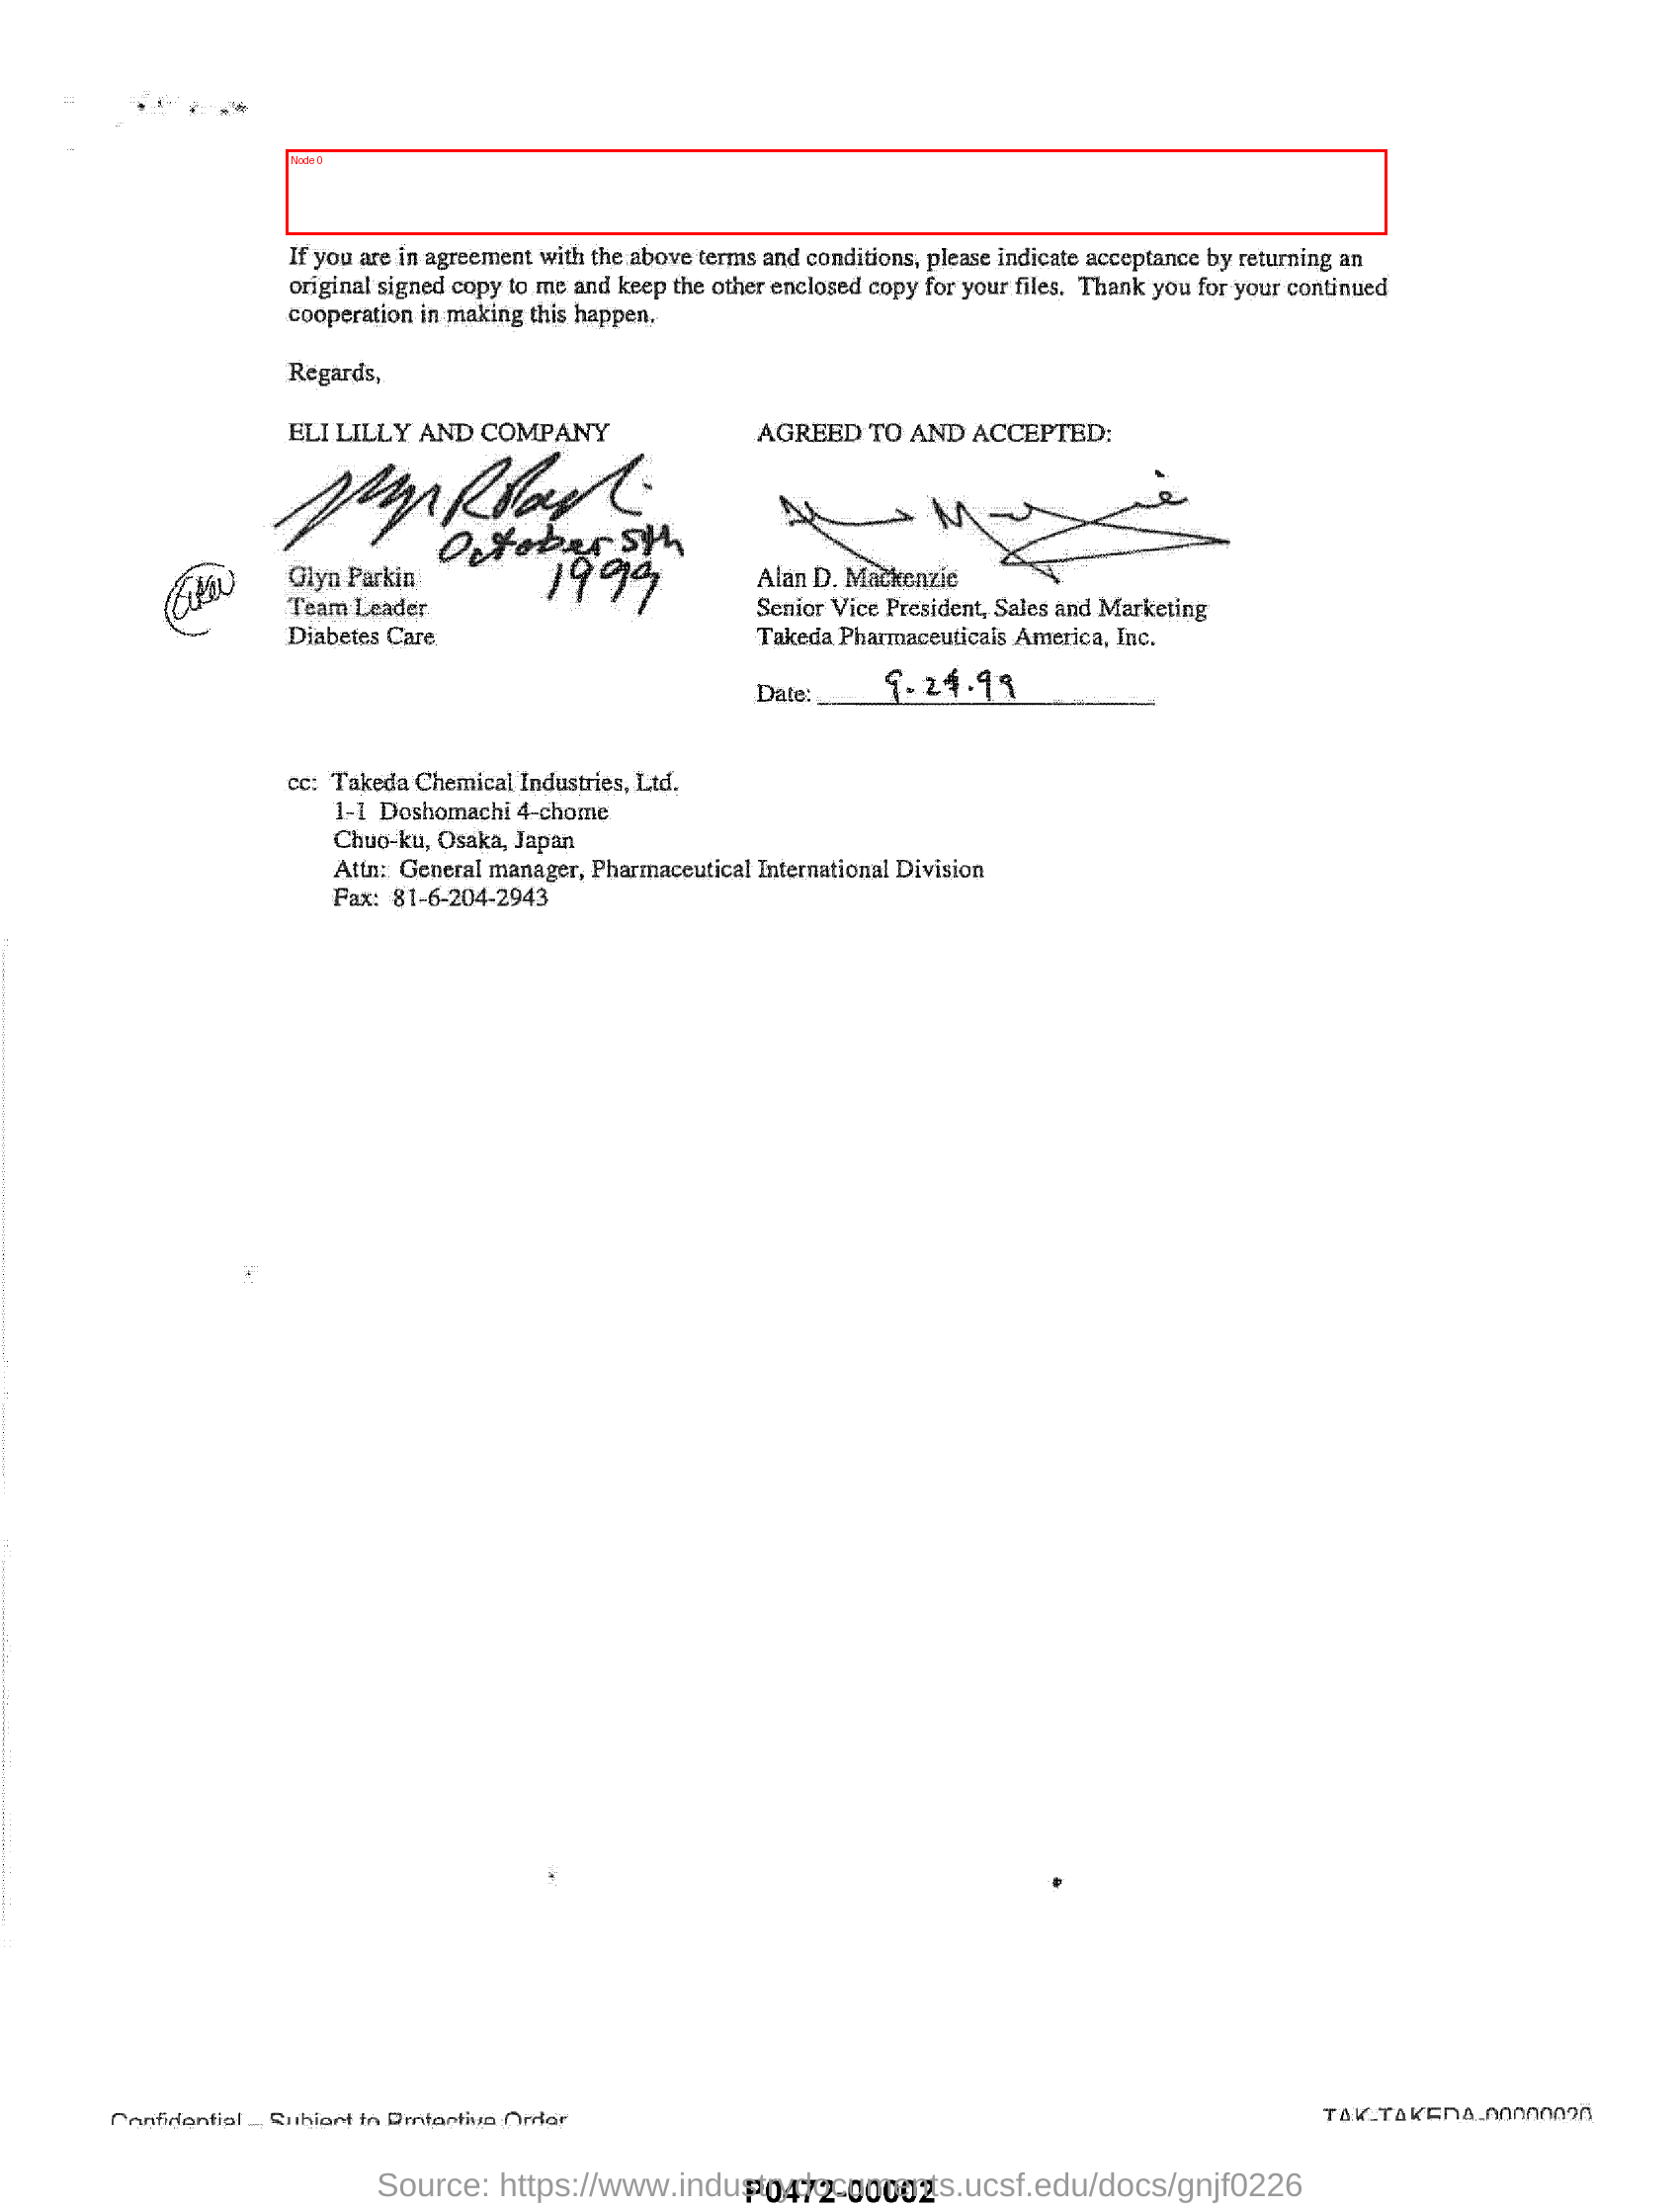

In [9]:
print("=" * 60)
print(" QA Examples with Evidence Visualization")
print("=" * 60)

if src_img_path and src_img_path.exists():
    # Show first 5 QA examples with evidence boxes
    for i, qa in enumerate(qas[:5]):
        print(f"\n{'='*60}")
        print(f" QA #{i+1}")
        print(f"{'='*60}")
        print(f" Question: {qa.get('question')}")
        print(f" Answer: {qa.get('answer')}")
        print(f" Evidence Regions: {qa.get('evidence_region_ids')}")
        print(f" Reasoning Type: {qa.get('reasoning_type')}")
        print(f" Explanation: {qa.get('reasoning_explanation', 'N/A')[:200]}")
        
        # Show evidence quotes
        quotes = qa.get('evidence_quotes', [])
        if quotes:
            print(f" Evidence Quotes:")
            for j, quote in enumerate(quotes[:2]):
                print(f"   [{j+1}] {quote[:150]}...")
        
        # Display image with boxes
        img = draw_evidence(src_img_path, qa.get("evidence_region_ids", []))
        display(img)
else:
    print(" No image found. Showing text-only examples:")
    for i, qa in enumerate(qas[:5]):
        print(f"\n{'='*60}")
        print(f" QA #{i+1}")
        print(f"{'='*60}")
        print(f" Question: {qa.get('question')}")
        print(f" Answer: {qa.get('answer')}")
        print(f" Evidence Regions: {qa.get('evidence_region_ids')}")
        print(f" Reasoning Type: {qa.get('reasoning_type')}")

## 4️. Batch Processing Multiple Documents

In [10]:
import os
from tqdm import tqdm

def process_batch(input_dir, max_docs=10, max_qas_per_doc=10):
    """Process multiple documents and collect QA statistics"""
    results = []
    doc_files = list(Path(input_dir).glob("*.json"))[:max_docs]
    
    print(f"Processing {len(doc_files)} documents from {input_dir}")
    
    for doc_path in tqdm(doc_files):
        try:
            doc_data = json.loads(doc_path.read_text(encoding="utf-8"))
            qas_generated = generate_qas(doc_data, rule_templates, llm_templates, max_qas=max_qas_per_doc)
            
            results.append({
                'doc_id': doc_path.stem,
                'num_nodes': len(doc_data.get('nodes', [])),
                'num_edges': len(doc_data.get('edges', [])),
                'num_qas': len(qas_generated),
                'reasoning_types': [qa.get('reasoning_type') for qa in qas_generated],
                'qas': qas_generated
            })
        except Exception as e:
            print(f"Error processing {doc_path.name}: {e}")
            continue
    
    return results

# Process a batch of test documents
batch_results = process_batch(BASE / "output/full_pipeline/test", max_docs=5, max_qas_per_doc=10)

Processing 5 documents from ..\output\full_pipeline\test


100%|██████████| 5/5 [00:00<00:00, 629.28it/s]


In [11]:
# Display batch statistics
print("=" * 60)
print(" Batch Processing Statistics")
print("=" * 60)

batch_df = pd.DataFrame([{
    'doc_id': r['doc_id'],
    'nodes': r['num_nodes'],
    'edges': r['num_edges'],
    'qas_generated': r['num_qas']
} for r in batch_results])

print(f"\n Summary:")
print(f"  - Total documents: {len(batch_results)}")
print(f"  - Total QAs generated: {batch_df['qas_generated'].sum()}")
print(f"  - Average QAs per document: {batch_df['qas_generated'].mean():.2f}")

# Aggregate reasoning types
all_reasoning_types = []
for r in batch_results:
    all_reasoning_types.extend(r['reasoning_types'])

print(f"\n Reasoning Type Distribution:")
for rtype, count in Counter(all_reasoning_types).items():
    print(f"  - {rtype}: {count} ({count/len(all_reasoning_types)*100:.1f}%)")

display(batch_df)

 Batch Processing Statistics

 Summary:
  - Total documents: 5
  - Total QAs generated: 14
  - Average QAs per document: 2.80

 Reasoning Type Distribution:
  - lookup: 9 (64.3%)
  - comprehension: 5 (35.7%)


,doc_id,nodes,edges,qas_generated
0,1016,3,6,3
1,1017,3,6,3
2,1019,3,6,3
3,1021,3,6,3
4,1027,7,35,2


## 5️. Save Generated QAs

In [12]:
# Save individual document QAs
OUTPUT_DIR = BASE / "output/qa_generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save single document QAs
single_doc_output = {
    "source_document": str(DOC_PATH.name),
    "num_qas": len(qas),
    "qas": qas
}

output_path = OUTPUT_DIR / f"{DOC_PATH.stem}_qas.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(single_doc_output, f, ensure_ascii=False, indent=2)

print(f" Saved {len(qas)} QAs to: {output_path}")

# Save batch results
batch_output = {
    "total_documents": len(batch_results),
    "total_qas": sum(r['num_qas'] for r in batch_results),
    "documents": [{
        "doc_id": r['doc_id'],
        "num_qas": r['num_qas'],
        "qas": r['qas']
    } for r in batch_results]
}

batch_output_path = OUTPUT_DIR / "batch_qas.json"
with open(batch_output_path, "w", encoding="utf-8") as f:
    json.dump(batch_output, f, ensure_ascii=False, indent=2)

print(f" Saved batch results ({batch_output['total_qas']} QAs) to: {batch_output_path}")

 Saved 3 QAs to: ..\output\qa_generated\1016_qas.json
 Saved batch results (14 QAs) to: ..\output\qa_generated\batch_qas.json


## 📝 Summary

**Logic của `src/qa/llm.py`:**

1. **Input**: Document graph JSON với `nodes` (regions) và `edges` (spatial relations)

2. **Rule-based Generation** (cho form/table/figure):
   - `gen_form_kv_qas()`: Trích xuất key-value pairs từ form → "What is the {key}?"
   - `gen_table_qas()`: Parse table → questions về headers, row count, cell lookup
   - `gen_figure_qas()`: "What does the figure show?" từ text description

3. **LLM-based Generation** (cho multi-region):
   - Tìm long text nodes (≥40 words)
   - Match cặp nodes qua edges → chọn template phù hợp
   - Nếu có local LLM (flan-t5): generate từ prompt
   - Nếu không: fallback deterministic (quote cả 2 regions)

4. **Output**: List QA pairs với `question`, `answer`, `evidence_region_ids`, `evidence_quotes`, `reasoning_type`

**Compatibility với codebase:** 
- Đọc đúng format JSON từ `full_pipeline` output (nodes, edges, adjacency)
- Templates trong `src/qa/` folder
- Export JSON format chuẩn